In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Nature-style configuration
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 100
})

# Base Parameters
t_max = 90
t_eval = np.linspace(0, t_max, 150)
y0 = [0.99, 0.01, 0.00] # S0, I0, R0

beta_true = 0.4
gamma_true = 0.1
R0_true = beta_true / gamma_true

def sir(t, y, b, g):
    S, I, R = y
    return [-b * S * I, b * S * I - g * I, g * I]

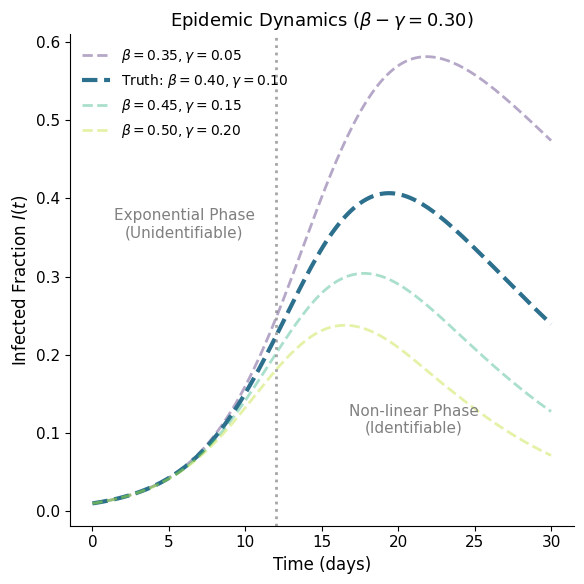

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Style Configuration
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# Base Parameters
t_max = 30
t_eval = np.linspace(0, t_max, 150)
y0 = [0.99, 0.01, 0.00] # S0, I0, R0

beta_true = 0.4
gamma_true = 0.1
r_true = beta_true - gamma_true

def sir(t, y, b, g):
    S, I, R = y
    return [-b * S * I, b * S * I - g * I, g * I]

def plot_figure_1_corrected():
    fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

    # Pairs (beta, gamma) that keep r = 0.30 constant
    ambiguous_pairs = [
        (0.35, 0.05),
        (0.40, 0.10), # True Target
        (0.45, 0.15),
        (0.50, 0.20)
    ]

    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(ambiguous_pairs)))

    for (b, g), color in zip(ambiguous_pairs, colors):
        sol = solve_ivp(sir, [0, t_max], y0, args=(b, g), t_eval=t_eval)
        lw = 3.0 if b == beta_true else 2.0
        alpha = 1.0 if b == beta_true else 0.4

        label_str = rf'Truth: $\beta={b:.2f}, \gamma={g:.2f}$' if b == beta_true else rf'$\beta={b:.2f}, \gamma={g:.2f}$'

        ax.plot(t_eval, sol.y[1], color=color, lw=lw, ls='--', alpha=alpha, label=label_str)

    # --- START OF REGIME MARKING ---
    t_transition = 12 # Breakpoint of linear approximation

    # Dividing Line
    ax.axvline(x=t_transition, color='gray', linestyle=':', lw=2, alpha=0.7)

    # Texts demarcating zones
    ax.text(t_transition / 2, 0.35, 'Exponential Phase\n(Unidentifiable)',
            horizontalalignment='center', color='gray', fontsize=11)
    ax.text(t_transition + (t_max - t_transition)/2, 0.1, 'Non-linear Phase\n(Identifiable)',
            horizontalalignment='center', color='gray', fontsize=11)
    # --- END OF REGIME MARKING ---

    ax.set_title(rf'Epidemic Dynamics ($β - γ = {r_true:.2f}$)')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Infected Fraction $I(t)$')
    ax.legend(frameon=False, loc='upper left')

    plt.tight_layout()
    plt.show()

plot_figure_1_corrected()

Calculating Hessians via finite differences...


/tmp/ipykernel_3932/3955695993.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


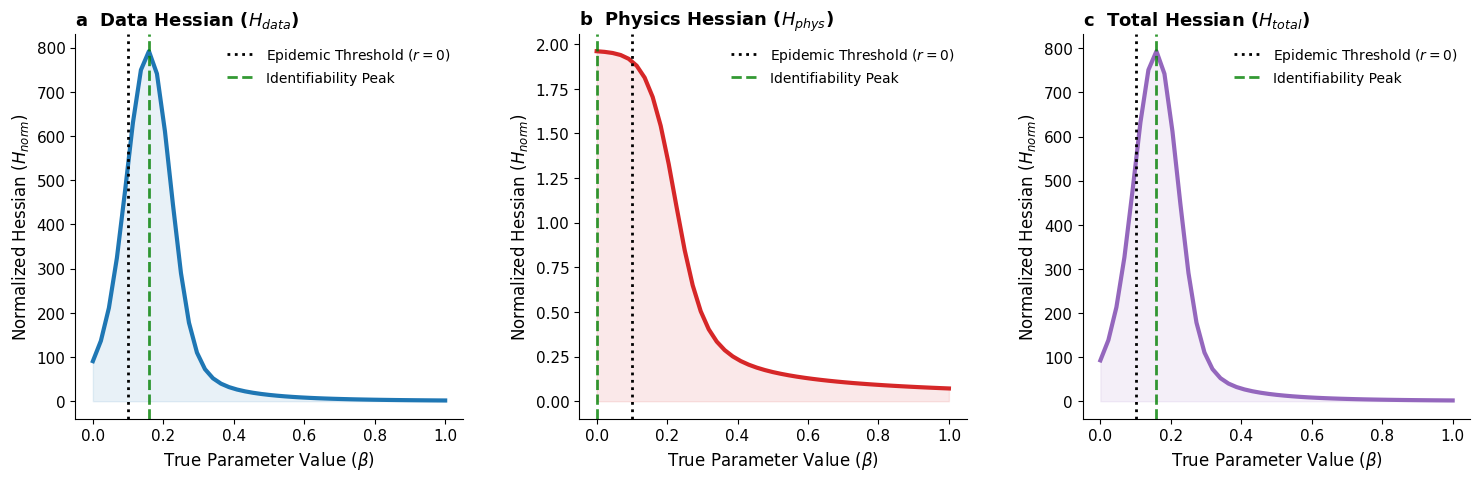

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.gridspec as gridspec

# Style Configuration
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 100
})

# Base Parameters
t_max = 30
t_eval = np.linspace(0, t_max, 150)
y0 = [0.99, 0.01, 0.00]

gamma_true = 0.1
lambda_phys = 1.0 # Scalarization weight

def sir(t, y, b, g):
    S, I, R = y
    return [-b * S * I, b * S * I - g * I, g * I]

def plot_hessian_scalarization_r():
    fig = plt.figure(figsize=(18, 5), dpi=100)
    gs = gridspec.GridSpec(1, 3, wspace=0.3)

    b_range = np.linspace(0.0, 1.0, 45)
    h_step = 0.005

    hn_data = []
    hn_phys = []
    hn_total = []

    print("Calculating Hessians via finite differences...")
    for b_val in b_range:
        # 1. Base Trajectory
        sol_ref = solve_ivp(sir, [0, t_max], y0, args=(b_val, gamma_true), t_eval=t_eval)
        S_ref = sol_ref.y[0]
        I_ref = sol_ref.y[1]
        dI_dt_ref = b_val * S_ref * I_ref - gamma_true * I_ref

        energy = np.sum(I_ref**2)

        loss_d = []
        loss_p = []

        # 2. Perturbations in beta
        for shift in [-h_step, 0, h_step]:
            b_shift = b_val + shift

            # Data Loss
            sol_shift = solve_ivp(sir, [0, t_max], y0, args=(b_shift, gamma_true), t_eval=t_eval)
            mse_data = np.sum((sol_shift.y[1] - I_ref)**2)
            loss_d.append(mse_data)

            # Physics Loss
            residual = dI_dt_ref - (b_shift * S_ref * I_ref - gamma_true * I_ref)
            mse_phys = np.sum(residual**2)
            loss_p.append(mse_phys)

        # 3. Central Derivative
        hess_data = (loss_d[2] - 2*loss_d[1] + loss_d[0]) / (h_step**2)
        hess_phys = (loss_p[2] - 2*loss_p[1] + loss_p[0]) / (h_step**2)
        hess_tot  = hess_data + lambda_phys * hess_phys

        # 4. Normalization
        if energy > 1e-8:
            hn_data.append(hess_data / energy)
            hn_phys.append(hess_phys / energy)
            hn_total.append(hess_tot / energy)
        else:
            hn_data.append(0)
            hn_phys.append(0)
            hn_total.append(0)

    def format_hessian_panel(ax, y_data, title, color):
        ax.plot(b_range, y_data, color=color, lw=3.0)
        ax.fill_between(b_range, 0, y_data, color=color, alpha=0.1)

        # The epidemic threshold is now focused on r = 0 (b_val = gamma_true)
        ax.axvline(x=gamma_true, color='black', linestyle=':', lw=2, label=r'Epidemic Threshold ($r=0$)')

        max_idx = np.argmax(y_data)
        ax.axvline(x=b_range[max_idx], color='green', linestyle='--', lw=2, alpha=0.8, label='Identifiability Peak')

        ax.set_title(title, loc='left', fontweight='bold')
        ax.set_xlabel(r'True Parameter Value ($β$)')
        ax.set_ylabel(r'Normalized Hessian ($H_{norm}$)')
        ax.legend(frameon=False, loc='upper right')

    ax1 = fig.add_subplot(gs[0])
    format_hessian_panel(ax1, hn_data, r'a  Data Hessian ($H_{data}$)', '#1f77b4')

    ax2 = fig.add_subplot(gs[1])
    format_hessian_panel(ax2, hn_phys, r'b  Physics Hessian ($H_{phys}$)', '#d62728')

    ax3 = fig.add_subplot(gs[2])
    format_hessian_panel(ax3, hn_total, r'c  Total Hessian ($H_{total}$)', '#9467bd')

    plt.tight_layout()
    plt.show()

plot_hessian_scalarization_r()

/tmp/ipykernel_3932/1562816074.py:14: RuntimeWarning: divide by zero encountered in divide
  ee_branch = 1 - (gamma / beta_range)


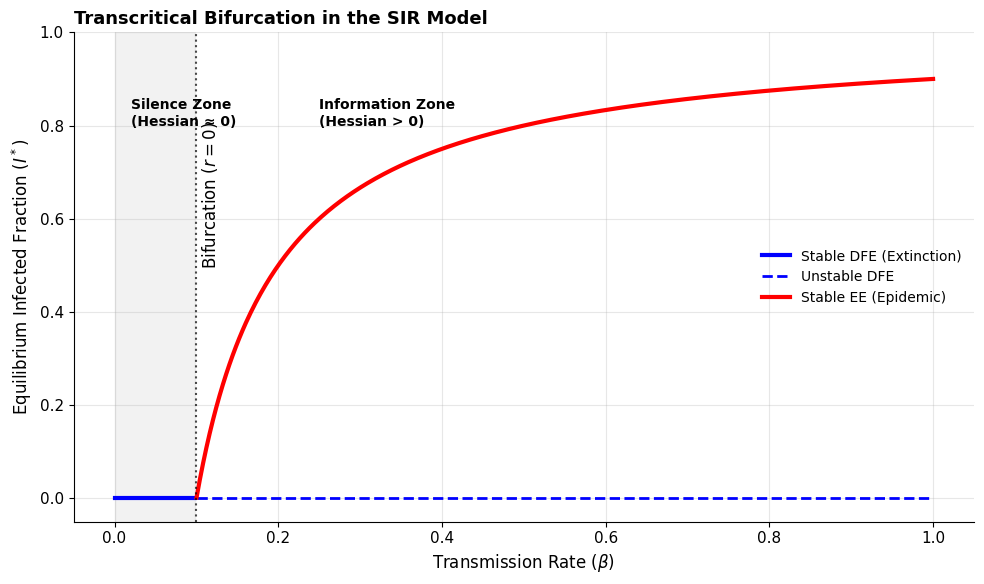

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sir_bifurcation():
    # Parameters
    gamma = 0.1
    beta_range = np.linspace(0, 1.0, 500)

    # Steady States
    # 1. Disease-Free Equilibrium (DFE): I* = 0
    # 2. Endemic Equilibrium (EE): I* = 1 - (gamma/beta)

    dfe_branch = np.zeros_like(beta_range)
    ee_branch = 1 - (gamma / beta_range)

    # Adjustment for physical values (I cannot be negative in EE)
    ee_branch[beta_range <= gamma] = np.nan

    plt.figure(figsize=(10, 6), dpi=100)

    # Plotting the Disease-Free Equilibrium (I*=0)
    # Stable when beta < gamma (r < 0)
    plt.plot(beta_range[beta_range <= gamma], dfe_branch[beta_range <= gamma],
             'b-', lw=3, label='Stable DFE (Extinction)')
    # Unstable when beta > gamma (r > 0)
    plt.plot(beta_range[beta_range > gamma], dfe_branch[beta_range > gamma],
             'b--', lw=2, label='Unstable DFE')

    # Plotting the Endemic Equilibrium
    # Stable when beta > gamma (r > 0)
    plt.plot(beta_range[beta_range > gamma], ee_branch[beta_range > gamma],
             'r-', lw=3, label='Stable EE (Epidemic)')

    # Critical Line (Bifurcation at r=0)
    plt.axvline(x=gamma, color='black', linestyle=':', alpha=0.7)
    plt.text(gamma + 0.005, 0.5, r'Bifurcation ($r=0$)', rotation=90, fontsize=12)

    # Analytical Annotations
    plt.fill_between(beta_range[beta_range <= gamma], -0.05, 1, color='gray', alpha=0.1)
    plt.text(0.02, 0.8, "Silence Zone\n(Hessian ≈ 0)", fontsize=10, fontweight='bold')
    plt.text(0.25, 0.8, "Information Zone\n(Hessian > 0)", fontsize=10, fontweight='bold')

    plt.title('Transcritical Bifurcation in the SIR Model', loc='left', fontweight='bold')
    plt.xlabel(r'Transmission Rate ($β$)')
    plt.ylabel(r'Equilibrium Infected Fraction ($I^*$)')
    plt.ylim(-0.05, 1.0)
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)

    plt.tight_layout()
    plt.show()

plot_sir_bifurcation()

Running Drift simulation (Beta=0.5)...
Running Real simulation (Beta=0.3)...


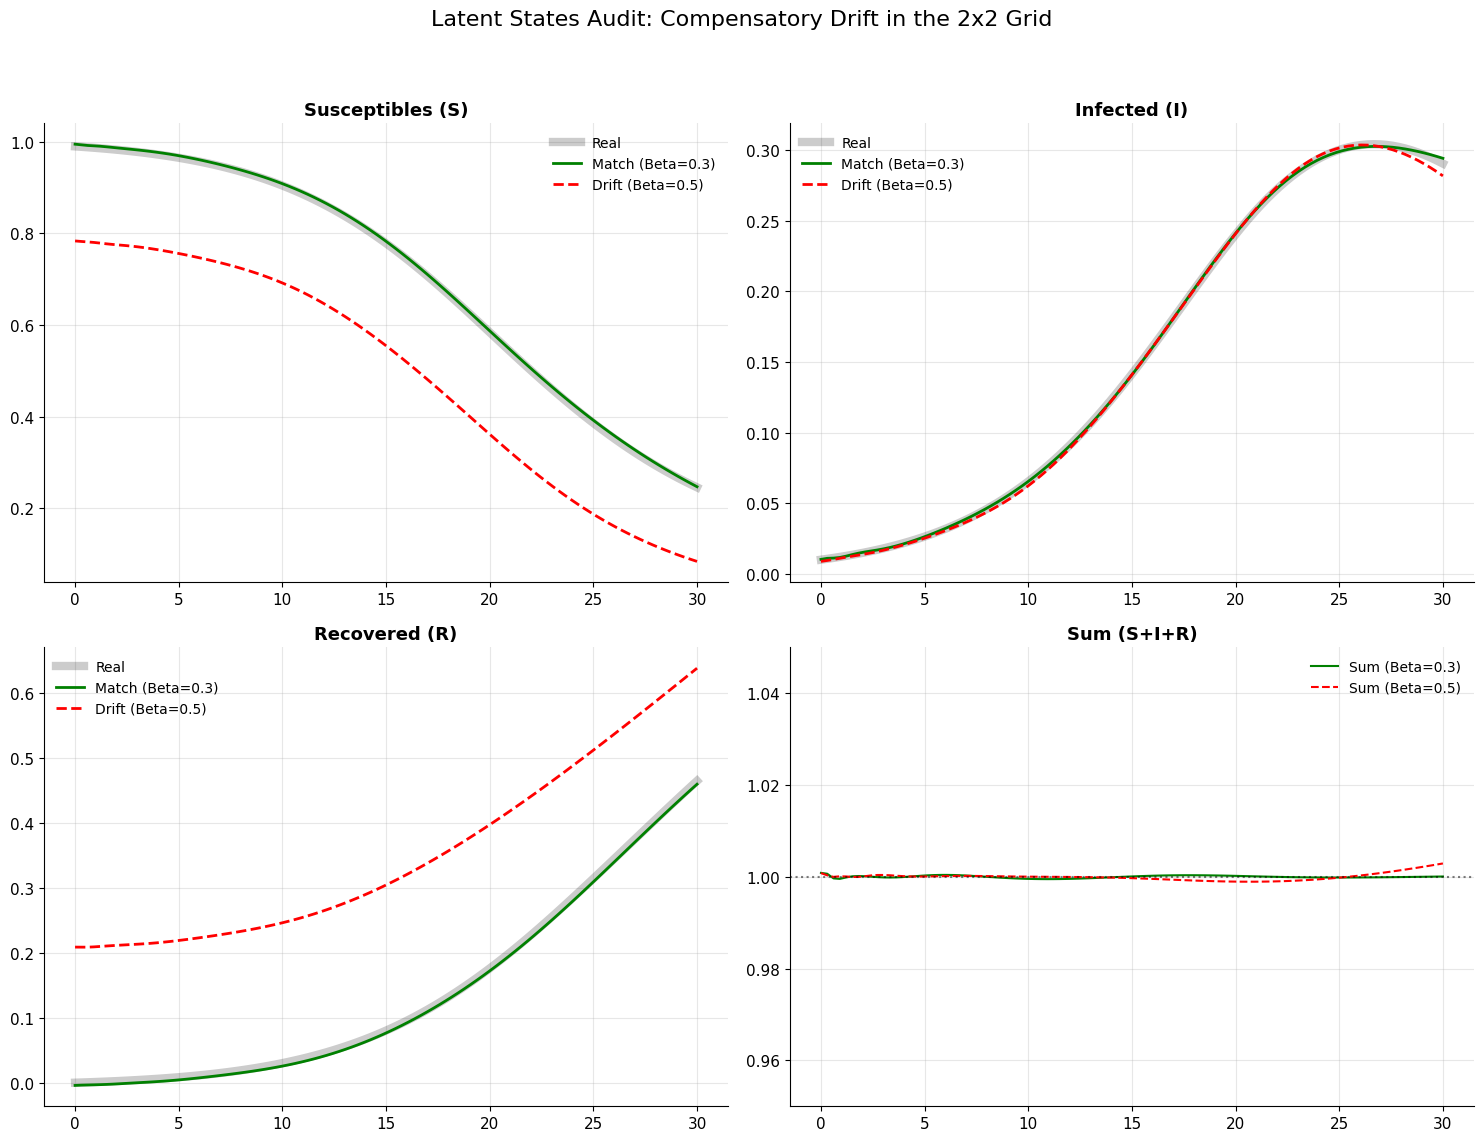

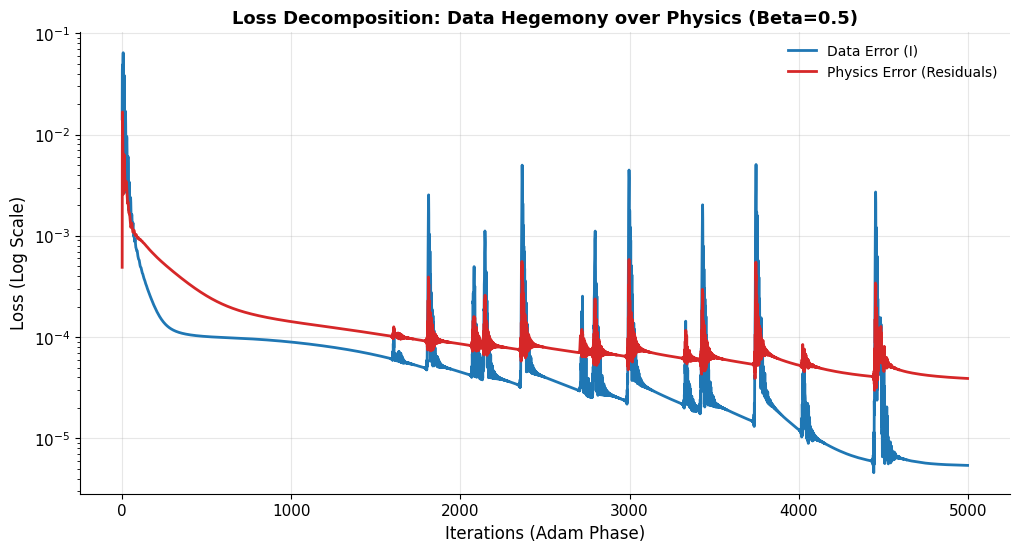

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Ground Truth (The Real) ---
t_max = 30
t_eval = np.linspace(0, t_max, 100)
beta_t, gamma_t = 0.3, 0.1
y0 = [0.99, 0.01, 0.0]

def sir_model(t, y, b, g):
    S, I, R = y
    return [-b*S*I, b*S*I - g*I, g*I]

sol = solve_ivp(sir_model, [0, t_max], y0, args=(beta_t, gamma_t), t_eval=t_eval)
I_obs = torch.tensor(sol.y[1], dtype=torch.float32).view(-1, 1).to(device)
t_tensor = torch.tensor(t_eval, dtype=torch.float32).view(-1, 1).to(device)

# --- 2. Robust PINN (128 Neurons) ---
class ResearchPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 3)
        )
    def forward(self, t): return self.net(t)

# --- 3. Hybrid Adam + L-BFGS Engine ---
def train_hybrid(beta_val):
    model = ResearchPINN().to(device)
    adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, line_search_fn="strong_wolfe")

    logs = {'data': [], 'phys': []}

    def get_loss():
        t_p = t_tensor.clone().requires_grad_(True)
        u = model(t_p); S, I, R = u[:,0:1], u[:,1:2], u[:,2:3]
        ds = torch.autograd.grad(S, t_p, torch.ones_like(S), create_graph=True)[0]
        di = torch.autograd.grad(I, t_p, torch.ones_like(I), create_graph=True)[0]
        dr = torch.autograd.grad(R, t_p, torch.ones_like(R), create_graph=True)[0]

        res_s = ds + beta_val * S * I
        res_i = di - (beta_val * S * I - gamma_t * I)
        res_r = dr - gamma_t * I

        l_phys = torch.mean(res_s**2 + res_i**2 + res_r**2)
        l_data = torch.mean((I - I_obs)**2)
        l_cons = torch.mean((S + I + R - 1.0)**2)
        return l_data + l_phys + l_cons, l_data, l_phys

    # Adam
    for _ in range(5000):
        adam.zero_grad()
        total, ld, lp = get_loss()
        total.backward(); adam.step()
        logs['data'].append(ld.item()); logs['phys'].append(lp.item())

    # L-BFGS
    def closure():
        lbfgs.zero_grad(); total, _, _ = get_loss()
        total.backward(); return total
    lbfgs.step(closure)

    return model, logs

print("Running Drift simulation (Beta=0.5)...")
model_d, logs_d = train_hybrid(0.5)
print("Running Real simulation (Beta=0.3)...")
model_t, _ = train_hybrid(0.3)

# --- 4. 2x2 Grid Plotting and Loss Graph ---
with torch.no_grad():
    res_t = model_t(t_tensor).cpu(); res_d = model_d(t_tensor).cpu()

# FIGURE 1: COMPARTMENT DYNAMICS
fig1, axs = plt.subplots(2, 2, figsize=(15, 12))
titles = ['Susceptibles (S)', 'Infected (I)', 'Recovered (R)', 'Sum (S+I+R)']
data_idx = [0, 1, 2]

for i in range(3):
    ax = axs[i//2, i%2]
    ax.plot(t_eval, sol.y[i], 'k-', alpha=0.2, lw=6, label='Real')
    ax.plot(t_eval, res_t[:, i], 'g-', lw=2, label='Match (Beta=0.3)')
    ax.plot(t_eval, res_d[:, i], 'r--', lw=2, label='Drift (Beta=0.5)')
    ax.set_title(titles[i], fontweight='bold'); ax.legend(frameon=False); ax.grid(alpha=0.3)

# Sum Panel (Mass Conservation)
ax_sum = axs[1, 1]
sum_t = torch.sum(res_t, dim=1); sum_d = torch.sum(res_d, dim=1)
ax_sum.plot(t_eval, sum_t, 'g-', label='Sum (Beta=0.3)')
ax_sum.plot(t_eval, sum_d, 'r--', label='Sum (Beta=0.5)')
ax_sum.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
ax_sum.set_title(titles[3], fontweight='bold'); ax_sum.set_ylim(0.95, 1.05)
ax_sum.legend(frameon=False); ax_sum.grid(alpha=0.3)

plt.suptitle("Latent States Audit: Compensatory Drift in the 2x2 Grid", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# FIGURE 2: LOSS DECOMPOSITION
plt.figure(figsize=(12, 6))
plt.plot(logs_d['data'], label='Data Error (I)', color='#1f77b4', lw=2)
plt.plot(logs_d['phys'], label='Physics Error (Residuals)', color='#d62728', lw=2)
plt.yscale('log')
plt.title('Loss Decomposition: Data Hegemony over Physics (Beta=0.5)', fontweight='bold')
plt.xlabel('Iterations (Adam Phase)'); plt.ylabel('Loss (Log Scale)'); plt.legend(frameon=False)
plt.grid(alpha=0.3)

plt.show()


Running simulation with WINDOW_DURATION = 30 days
Training Window 1/3 (Days 0-30)...
Training Window 2/3 (Days 30-60)...
Training Window 3/3 (Days 60-90)...


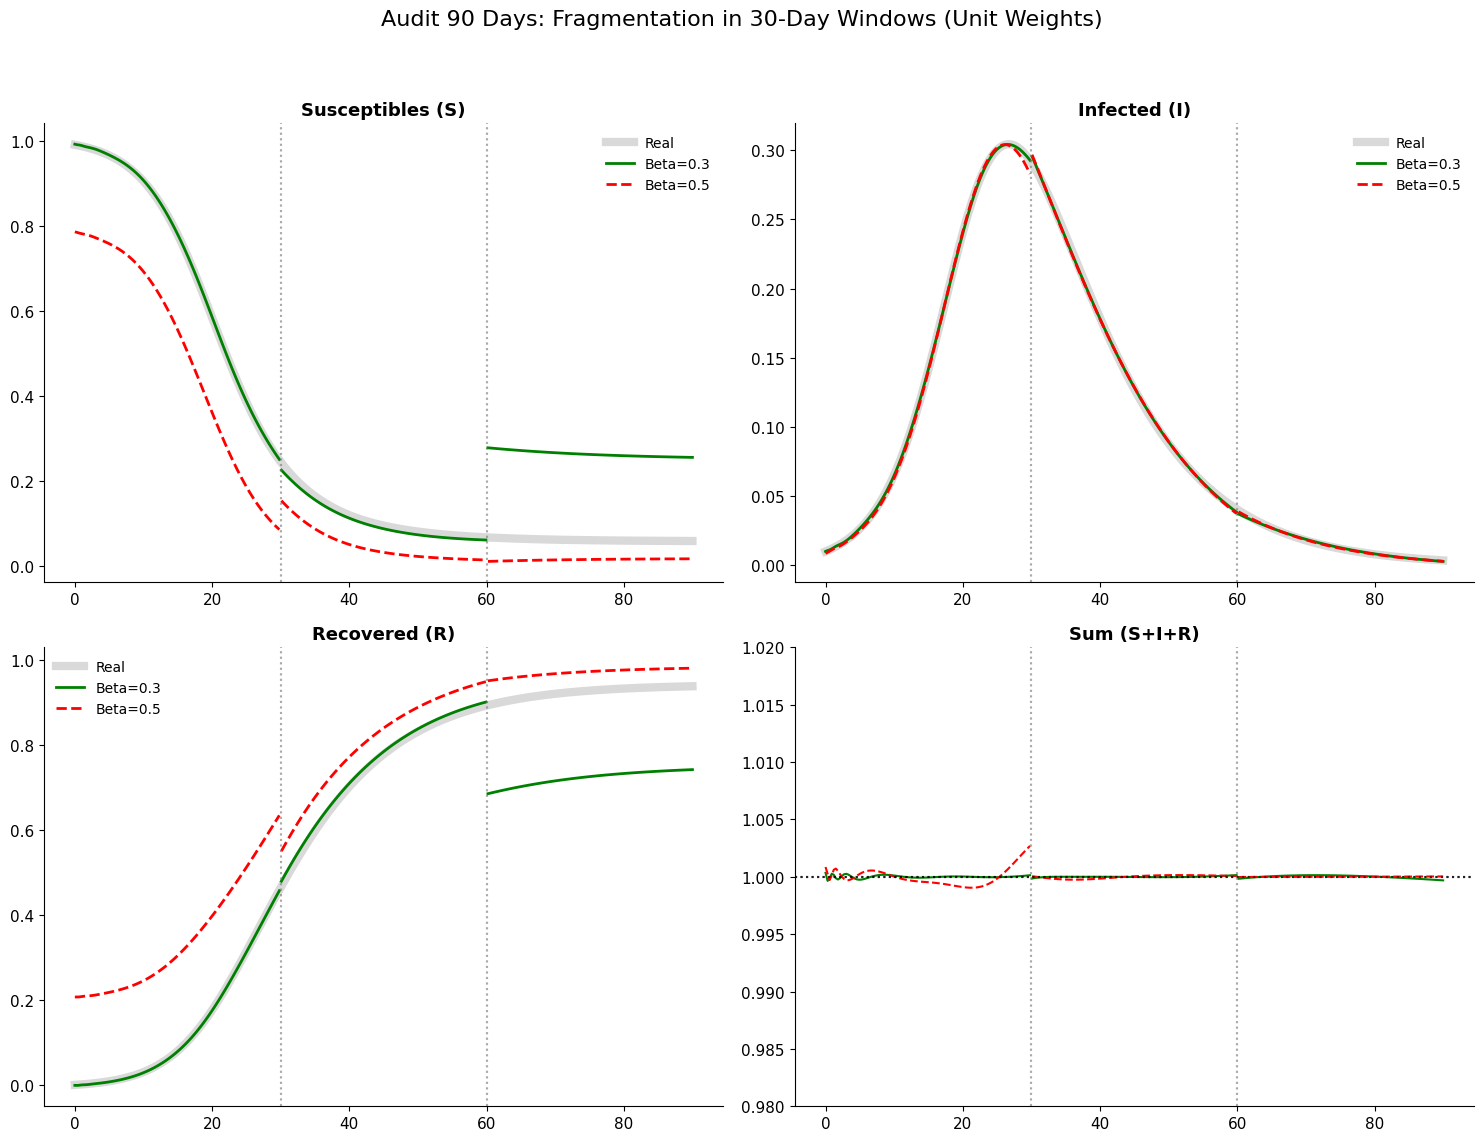

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Global configuration
torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Ground Truth (90 days) ---
t_max = 90
t_eval = np.linspace(0, t_max, 300)
beta_t, gamma_t = 0.3, 0.1
y0 = [0.99, 0.01, 0.0]

def sir_model(t, y, b, g):
    S, I, R = y
    return [-b*S*I, b*S*I - g*I, g*I]

sol = solve_ivp(sir_model, [0, t_max], y0, args=(beta_t, gamma_t), t_eval=t_eval)

# --- 2. Robust PINN (128 Neurons) ---
class ResearchPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 3)
        )
    def forward(self, t): return self.net(t)

# --- 3. Windowed Training Engine (Logic Maintained) ---
def train_window(t_slice, I_slice, beta_val):
    model = ResearchPINN().to(device)
    adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, line_search_fn="strong_wolfe")

    t_tensor_win = torch.tensor(t_slice, dtype=torch.float32).view(-1, 1).to(device)
    I_obs_win = torch.tensor(I_slice, dtype=torch.float32).view(-1, 1).to(device)

    def get_loss():
        t_p = t_tensor_win.clone().requires_grad_(True)
        u = model(t_p); S, I, R = u[:,0:1], u[:,1:2], u[:,2:3]

        ds = torch.autograd.grad(S, t_p, torch.ones_like(S), create_graph=True)[0]
        di = torch.autograd.grad(I, t_p, torch.ones_like(I), create_graph=True)[0]
        dr = torch.autograd.grad(R, t_p, torch.ones_like(R), create_graph=True)[0]

        res_s = ds + beta_val * S * I
        res_i = di - (beta_val * S * I - gamma_t * I)
        res_r = dr - gamma_t * I

        l_phys = torch.mean(res_s**2 + res_i**2 + res_r**2)
        l_data = torch.mean((I - I_obs_win)**2)
        l_cons = torch.mean((S + I + R - 1.0)**2)

        # Unit weights maintained as requested
        return l_data + l_phys + l_cons, l_data, l_phys

    for _ in range(5000):
        adam.zero_grad()
        total, _, _ = get_loss()
        total.backward(); adam.step()

    def closure():
        lbfgs.zero_grad(); total, _, _ = get_loss()
        total.backward(); return total
    lbfgs.step(closure)

    return model

def run_windowed_simulation(window_duration_param):
    """Runs the windowed PINN simulation for a given window duration and plots the results."""

    window_limits = np.arange(0, t_max + 1, window_duration_param) # Generate window boundaries
    num_windows = len(window_limits) - 1

    results_t = [] # Beta=0.3
    results_d = [] # Beta=0.5

    if num_windows <= 0:
        print(f"Window duration {window_duration_param} is too large or invalid for t_max={t_max}. Skipping simulation.")
        return

    print(f"\nRunning simulation with WINDOW_DURATION = {window_duration_param} days")
    for i in range(num_windows):
        start, end = window_limits[i], window_limits[i+1]
        mask = (t_eval >= start) & (t_eval <= end)
        t_win, I_win = t_eval[mask], sol.y[1][mask]

        print(f"Training Window {i+1}/{num_windows} (Days {start}-{end})...")
        m_t = train_window(t_win, I_win, 0.3)
        m_d = train_window(t_win, I_win, 0.5)

        with torch.no_grad():
            t_ten = torch.tensor(t_win, dtype=torch.float32).view(-1, 1).to(device)
            results_t.append(m_t(t_ten).cpu().numpy())
            results_d.append(m_d(t_ten).cpu().numpy())

    # --- 5. 2x2 Grid Visualization ---
    plt.figure(figsize=(15, 12))
    titles = ['Susceptibles (S)', 'Infected (I)', 'Recovered (R)', 'Sum (S+I+R)']

    for i in range(num_windows):
        start, end = window_limits[i], window_limits[i+1]
        mask = (t_eval >= start) & (t_eval <= end)
        t_win = t_eval[mask]

        res_t = results_t[i]
        res_d = results_d[i]

        for j in range(3):
            ax = plt.subplot(2, 2, j+1)
            if i == 0: ax.plot(t_eval, sol.y[j], 'k-', alpha=0.15, lw=6, label='Real')
            ax.plot(t_win, res_t[:, j], 'g-', lw=2, label='Beta=0.3' if i==0 else "")
            ax.plot(t_win, res_d[:, j], 'r--', lw=2, label='Beta=0.5' if i==0 else "")
            ax.set_title(titles[j], fontweight='bold')
            # Add vertical lines for all window boundaries except the last one
            for k in range(1, len(window_limits) - 1):
                ax.axvline(x=window_limits[k], color='gray', linestyle=':', alpha=0.3)
            if i == 0: ax.legend(frameon=False)

        # Sum Panel
        ax_s = plt.subplot(2, 2, 4)
        ax_s.plot(t_win, np.sum(res_t, axis=1), 'g-')
        ax_s.plot(t_win, np.sum(res_d, axis=1), 'r--')
        ax_s.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
        # Add vertical lines for all window boundaries except the last one
        for k in range(1, len(window_limits) - 1):
            ax_s.axvline(x=window_limits[k], color='gray', linestyle=':', alpha=0.3)
        ax_s.set_title(titles[3], fontweight='bold'); ax_s.set_ylim(0.98, 1.02)

    plt.suptitle(f"Audit {t_max} Days: Fragmentation in {window_duration_param}-Day Windows (Unit Weights)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the simulation for the default 30-day window
run_windowed_simulation(30)

Training Green Window 1/3 (Beta 0.3)...
Training Red Window 1/3 (Beta 0.5)...
Training Green Window 2/3 (Beta 0.3)...
Training Red Window 2/3 (Beta 0.3)...
Training Green Window 3/3 (Beta 0.3)...
Training Red Window 3/3 (Beta 0.3)...


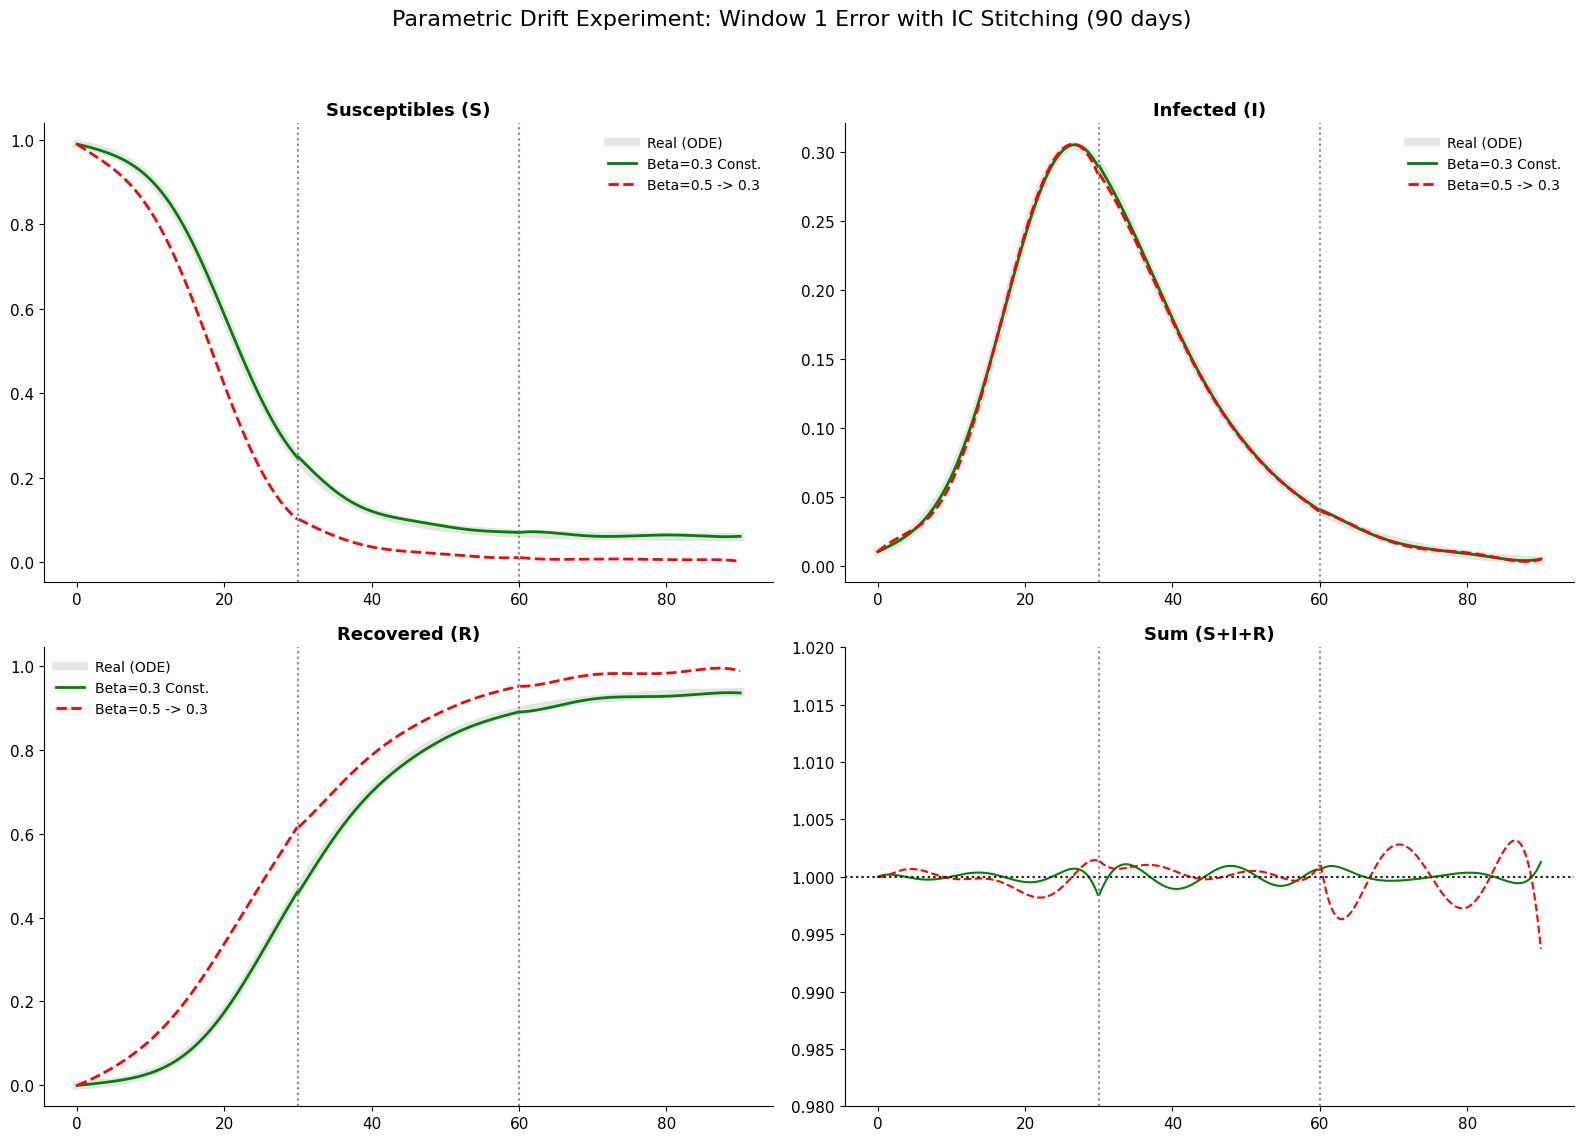

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Dtype synchronization to float32
torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Ground Truth (90 days) ---
t_max, beta_true, gamma_t = 90, 0.3, 0.1
t_eval = np.linspace(0, t_max, 450)
y0_real = [0.99, 0.01, 0.0]

def sir_model(t, y, b, g):
    S, I, R = y
    return [-b*S*I, b*S*I - g*I, g*I]

sol = solve_ivp(sir_model, [0, t_max], y0_real, args=(beta_true, gamma_t), t_eval=t_eval)

# --- 2. PINN with Hard IC (Structural Reinforcement) ---
class ResearchPINN_HardIC(nn.Module):
    def __init__(self, u0, t0, t1):
        super().__init__()
        self.t0, self.t1 = t0, t1
        self.register_buffer("u0_fixed", u0.clone().detach().float().view(1, 3))

        self.net = nn.Sequential(
            nn.Linear(1, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 3)
        )

    def forward(self, t):
        t_norm = 2.0 * (t - self.t0) / (self.t1 - self.t0) - 1.0
        phi = (t - self.t0)
        return self.u0_fixed + phi * self.net(t_norm)

# --- 3. Training Engine ---
def train_window(t_slice, I_slice, u0_start, beta_val):
    t_start, t_end = t_slice[0], t_slice[-1]
    model = ResearchPINN_HardIC(u0_start, t_start, t_end).to(device)

    adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, line_search_fn="strong_wolfe")

    t_tensor_win = torch.tensor(t_slice, dtype=torch.float32).view(-1, 1).to(device)
    I_obs_win = torch.tensor(I_slice, dtype=torch.float32).view(-1, 1).to(device)

    def get_loss():
        t_p = t_tensor_win.clone().requires_grad_(True)
        u = model(t_p); S, I, R = u[:, 0:1], u[:, 1:2], u[:, 2:3]

        ds = torch.autograd.grad(S, t_p, torch.ones_like(S), create_graph=True)[0]
        di = torch.autograd.grad(I, t_p, torch.ones_like(I), create_graph=True)[0]
        dr = torch.autograd.grad(R, t_p, torch.ones_like(R), create_graph=True)[0]

        res_s = ds + beta_val * S * I
        res_i = di - (beta_val * S * I - gamma_t * I)
        res_r = dr - gamma_t * I

        l_phys = torch.mean(res_s**2 + res_i**2 + res_r**2)
        l_data = torch.mean((I - I_obs_win)**2)
        l_cons = torch.mean((S + I + R - 1.0)**2)

        return l_data + l_phys + l_cons, l_data, l_phys

    for _ in range(5000):
        adam.zero_grad(); total, _, _ = get_loss(); total.backward(); adam.step()

    def closure():
        lbfgs.zero_grad(); total, _, _ = get_loss(); total.backward(); return total
    lbfgs.step(closure)

    return model

# --- 4. Execution of 3-Window Loop (Green vs Red) ---
window_limits = [0, 30, 60, 90]
models_green, models_red = [], []
u0_g = torch.tensor([0.99, 0.01, 0.0])
u0_r = torch.tensor([0.99, 0.01, 0.0])

for i in range(3):
    start, end = window_limits[i], window_limits[i+1]
    mask = (t_eval >= start) & (t_eval <= end)
    t_win, I_win = t_eval[mask], sol.y[1][mask]

    # Green Case: Beta 0.3 in all windows
    print(f"Training Green Window {i+1}/3 (Beta 0.3)...")
    m_g = train_window(t_win, I_win, u0_g, 0.3)
    models_green.append(m_g)

    # Red Case: Beta 0.5 in Window 1, Beta 0.3 in Windows 2 and 3
    beta_red = 0.5 if i == 0 else 0.3
    print(f"Training Red Window {i+1}/3 (Beta {beta_red})...")
    m_r = train_window(t_win, I_win, u0_r, beta_red)
    models_red.append(m_r)

    with torch.no_grad():
        last_t = torch.tensor([[t_win[-1]]], device=device).float()
        u0_g = m_g(last_t).squeeze().cpu()
        u0_r = m_r(last_t).squeeze().cpu()

# --- 5. Visualization ---
plt.figure(figsize=(16, 12))
titles = ['Susceptibles (S)', 'Infected (I)', 'Recovered (R)', 'Sum (S+I+R)']

with torch.no_grad():
    for i in range(3):
        mask = (t_eval >= window_limits[i]) & (t_eval <= window_limits[i+1])
        t_plot = torch.tensor(t_eval[mask], dtype=torch.float32).view(-1, 1).to(device)

        res_g = models_green[i](t_plot).cpu().numpy()
        res_r = models_red[i](t_plot).cpu().numpy()

        for j in range(3):
            ax = plt.subplot(2, 2, j+1)
            if i == 0: ax.plot(t_eval, sol.y[j], 'k-', alpha=0.1, lw=6, label='Real (ODE)')
            ax.plot(t_eval[mask], res_g[:, j], 'g-', lw=2, label='Beta=0.3 Const.' if i==0 else "")
            ax.plot(t_eval[mask], res_r[:, j], 'r--', lw=2, label='Beta=0.5 -> 0.3' if i==0 else "")
            ax.set_title(titles[j], fontweight='bold')
            ax.axvline(x=30, color='gray', linestyle=':', alpha=0.5)
            ax.axvline(x=60, color='gray', linestyle=':', alpha=0.5)
            if i == 0: ax.legend(frameon=False)

        ax_s = plt.subplot(2, 2, 4)
        ax_s.plot(t_eval[mask], np.sum(res_g, axis=1), 'g-')
        ax_s.plot(t_eval[mask], np.sum(res_r, axis=1), 'r--')
        ax_s.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
        ax_s.axvline(x=30, color='gray', linestyle=':', alpha=0.5)
        ax_s.axvline(x=60, color='gray', linestyle=':', alpha=0.5)
        ax_s.set_title(titles[3], fontweight='bold'); ax_s.set_ylim(0.98, 1.02)

plt.suptitle("Parametric Drift Experiment: Window 1 Error with IC Stitching (90 days)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Running simulation with WINDOW_DURATION = 30 days (Hard ICs)
Training Green Window 1/3 (Beta 0.3)...
Training Red Window 1/3 (Beta 0.5)...
Training Green Window 2/3 (Beta 0.3)...
Training Red Window 2/3 (Beta 0.3)...
Training Green Window 3/3 (Beta 0.3)...
Training Red Window 3/3 (Beta 0.3)...


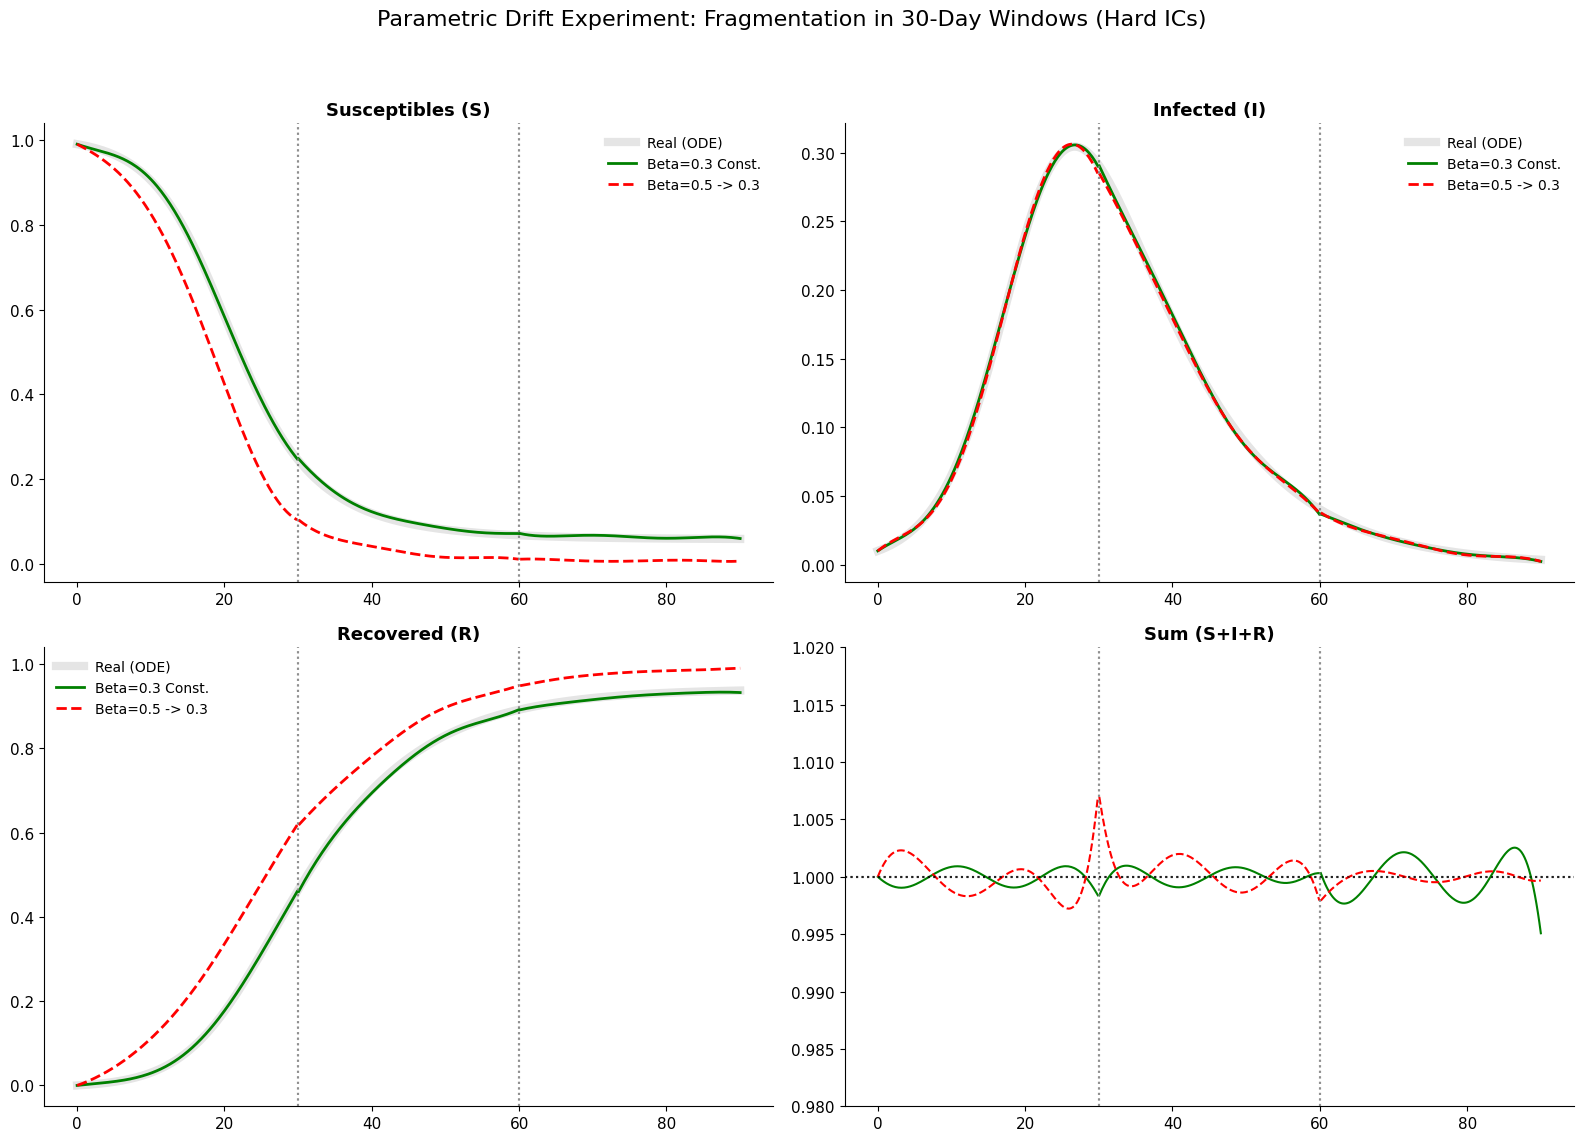

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Dtype synchronization to float32
torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Ground Truth (90 days) ---
t_max, beta_true, gamma_t = 90, 0.3, 0.1
t_eval = np.linspace(0, t_max, 450)
y0_real = [0.99, 0.01, 0.0]

def sir_model(t, y, b, g):
    S, I, R = y
    return [-b*S*I, b*S*I - g*I, g*I]

sol = solve_ivp(sir_model, [0, t_max], y0_real, args=(beta_true, gamma_t), t_eval=t_eval)

# --- 2. PINN with Hard IC (Structural Reinforcement) ---
class ResearchPINN_HardIC(nn.Module):
    def __init__(self, u0, t0, t1):
        super().__init__()
        self.t0, self.t1 = t0, t1
        self.register_buffer("u0_fixed", u0.clone().detach().float().view(1, 3))

        self.net = nn.Sequential(
            nn.Linear(1, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 3)
        )

    def forward(self, t):
        t_norm = 2.0 * (t - self.t0) / (self.t1 - self.t0) - 1.0
        phi = (t - self.t0)
        return self.u0_fixed + phi * self.net(t_norm)

# --- 3. Training Engine ---
def train_window(t_slice, I_slice, u0_start, beta_val):
    t_start, t_end = t_slice[0], t_slice[-1]
    model = ResearchPINN_HardIC(u0_start, t_start, t_end).to(device)

    adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, line_search_fn="strong_wolfe")

    t_tensor_win = torch.tensor(t_slice, dtype=torch.float32).view(-1, 1).to(device)
    I_obs_win = torch.tensor(I_slice, dtype=torch.float32).view(-1, 1).to(device)

    def get_loss():
        t_p = t_tensor_win.clone().requires_grad_(True)
        u = model(t_p); S, I, R = u[:, 0:1], u[:, 1:2], u[:, 2:3]

        ds = torch.autograd.grad(S, t_p, torch.ones_like(S), create_graph=True)[0]
        di = torch.autograd.grad(I, t_p, torch.ones_like(I), create_graph=True)[0]
        dr = torch.autograd.grad(R, t_p, torch.ones_like(R), create_graph=True)[0]

        res_s = ds + beta_val * S * I
        res_i = di - (beta_val * S * I - gamma_t * I)
        res_r = dr - gamma_t * I

        l_phys = torch.mean(res_s**2 + res_i**2 + res_r**2)
        l_data = torch.mean((I - I_obs_win)**2)
        l_cons = torch.mean((S + I + R - 1.0)**2)

        return l_data + l_phys + l_cons, l_data, l_phys

    for _ in range(5000):
        adam.zero_grad(); total, _, _ = get_loss(); total.backward(); adam.step()

    def closure():
        lbfgs.zero_grad(); total, _, _ = get_loss(); total.backward(); return total
    lbfgs.step(closure)

    return model

def run_windowed_simulation_hard_ic(window_duration_param):
    """Runs the windowed PINN simulation with hard ICs for a given window duration and plots the results."""

    window_limits = np.arange(0, t_max + 1, window_duration_param) # Generate window boundaries
    num_windows = len(window_limits) - 1

    models_green, models_red = [], []
    u0_g = torch.tensor(y0_real)
    u0_r = torch.tensor(y0_real)

    if num_windows <= 0:
        print(f"Window duration {window_duration_param} is too large or invalid for t_max={t_max}. Skipping simulation.")
        return

    print(f"\nRunning simulation with WINDOW_DURATION = {window_duration_param} days (Hard ICs)")
    for i in range(num_windows):
        start, end = window_limits[i], window_limits[i+1]
        mask = (t_eval >= start) & (t_eval <= end)
        t_win, I_win = t_eval[mask], sol.y[1][mask]

        # Green Case: Beta 0.3 in all windows
        print(f"Training Green Window {i+1}/{num_windows} (Beta 0.3)...")
        m_g = train_window(t_win, I_win, u0_g, 0.3)
        models_green.append(m_g)

        # Red Case: Beta 0.5 in Window 1, Beta 0.3 in subsequent Windows
        beta_red = 0.5 if i == 0 else 0.3
        print(f"Training Red Window {i+1}/{num_windows} (Beta {beta_red})...")
        m_r = train_window(t_win, I_win, u0_r, beta_red)
        models_red.append(m_r)

        with torch.no_grad():
            # Update u0_g and u0_r for the next window by getting the last state of the current window
            last_t = torch.tensor([[t_win[-1]]], device=device).float()
            u0_g = m_g(last_t).squeeze().cpu()
            u0_r = m_r(last_t).squeeze().cpu()

    # --- 5. Visualization ---
    plt.figure(figsize=(16, 12))
    titles = ['Susceptibles (S)', 'Infected (I)', 'Recovered (R)', 'Sum (S+I+R)']

    with torch.no_grad():
        for i in range(num_windows):
            mask = (t_eval >= window_limits[i]) & (t_eval <= window_limits[i+1])
            t_plot = torch.tensor(t_eval[mask], dtype=torch.float32).view(-1, 1).to(device)

            res_g = models_green[i](t_plot).cpu().numpy()
            res_r = models_red[i](t_plot).cpu().numpy()

            for j in range(3):
                ax = plt.subplot(2, 2, j+1)
                if i == 0: ax.plot(t_eval, sol.y[j], 'k-', alpha=0.1, lw=6, label='Real (ODE)')
                ax.plot(t_eval[mask], res_g[:, j], 'g-', lw=2, label='Beta=0.3 Const.' if i==0 else "")
                ax.plot(t_eval[mask], res_r[:, j], 'r--', lw=2, label='Beta=0.5 -> 0.3' if i==0 else "")
                ax.set_title(titles[j], fontweight='bold')
                # Add vertical lines for all window boundaries except the last one
                for k in range(1, len(window_limits) - 1):
                    ax.axvline(x=window_limits[k], color='gray', linestyle=':', alpha=0.5)
                if i == 0: ax.legend(frameon=False)

            ax_s = plt.subplot(2, 2, 4)
            ax_s.plot(t_eval[mask], np.sum(res_g, axis=1), 'g-')
            ax_s.plot(t_eval[mask], np.sum(res_r, axis=1), 'r--')
            ax_s.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
            # Add vertical lines for all window boundaries except the last one
            for k in range(1, len(window_limits) - 1):
                ax_s.axvline(x=window_limits[k], color='gray', linestyle=':', alpha=0.5)
            ax_s.set_title(titles[3], fontweight='bold'); ax_s.set_ylim(0.98, 1.02)

    plt.suptitle(f"Parametric Drift Experiment: Fragmentation in {window_duration_param}-Day Windows (Hard ICs)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Call the new function with a default window duration ---
run_windowed_simulation_hard_ic(30)


Running simulation with WINDOW_DURATION = 45 days (Hard ICs)
Training Green Window 1/2 (Beta 0.3)...
Training Red Window 1/2 (Beta 0.5)...
Training Green Window 2/2 (Beta 0.3)...
Training Red Window 2/2 (Beta 0.3)...


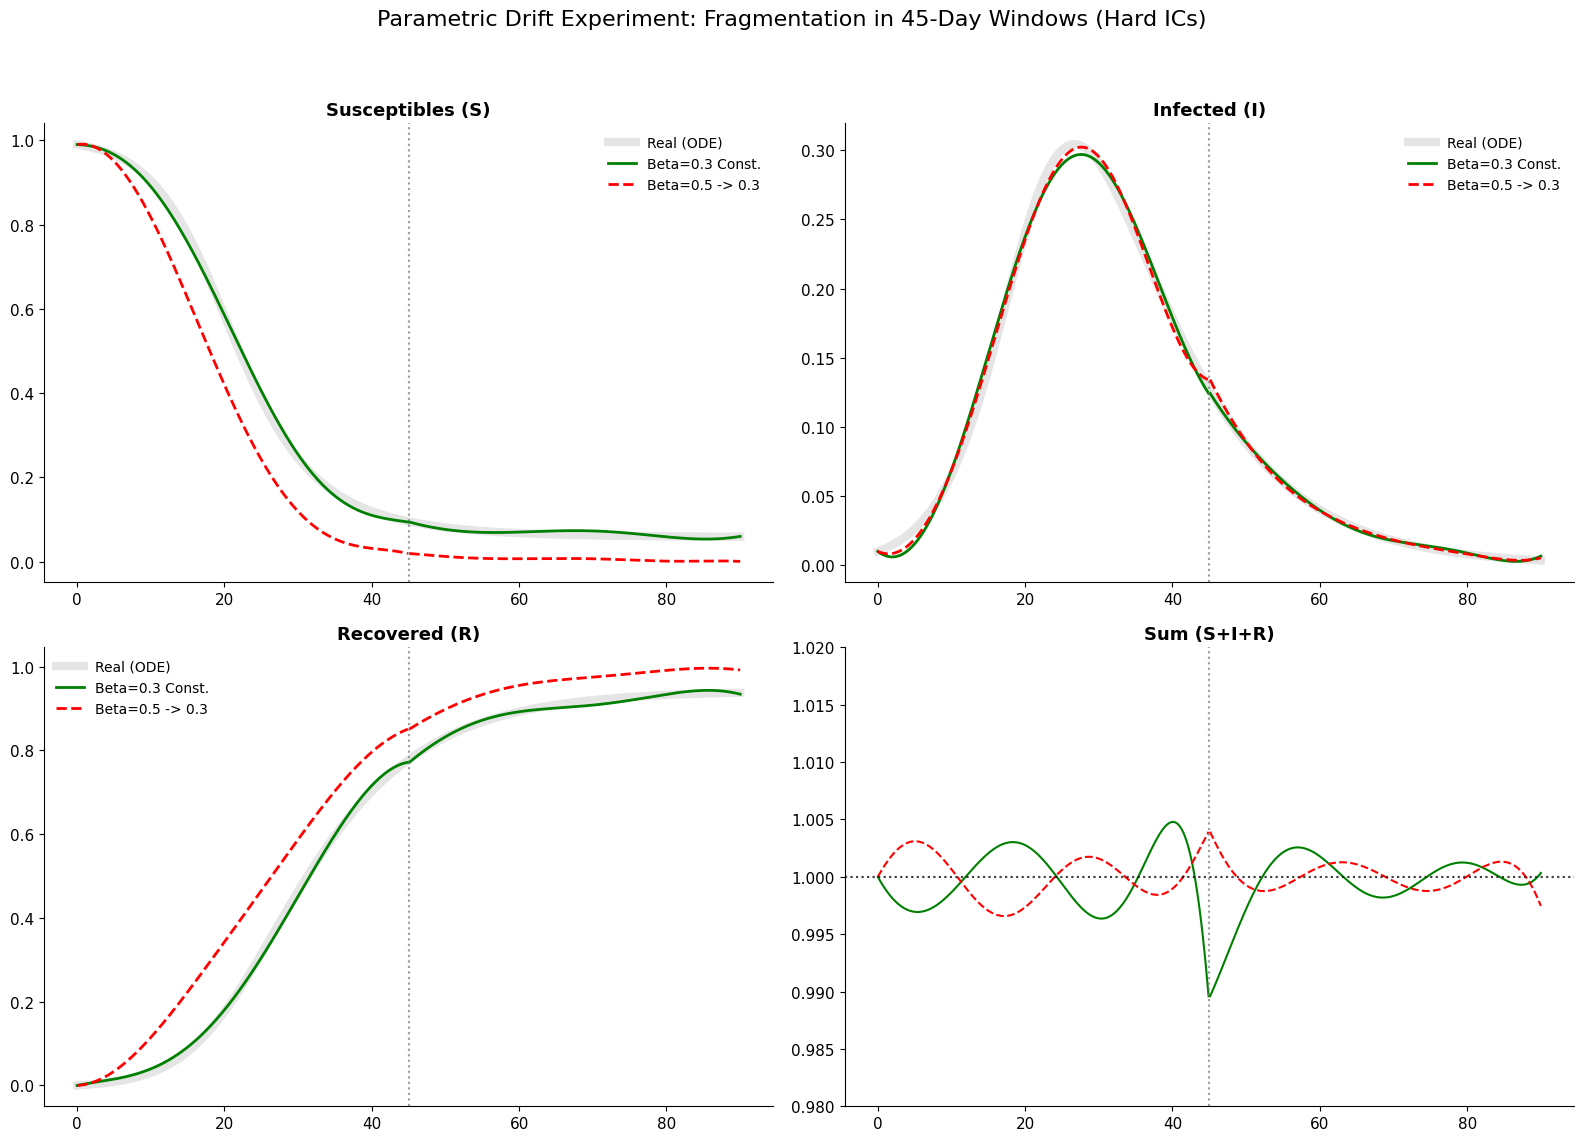

In [ ]:
run_windowed_simulation_hard_ic(45)


Running simulation with WINDOW_DURATION = 7 days (Hard ICs)
Training Green Window 1/12 (Beta 0.3)...
Training Red Window 1/12 (Beta 0.5)...
Training Green Window 2/12 (Beta 0.3)...
Training Red Window 2/12 (Beta 0.3)...
Training Green Window 3/12 (Beta 0.3)...
Training Red Window 3/12 (Beta 0.3)...
Training Green Window 4/12 (Beta 0.3)...
Training Red Window 4/12 (Beta 0.3)...
Training Green Window 5/12 (Beta 0.3)...
Training Red Window 5/12 (Beta 0.3)...
Training Green Window 6/12 (Beta 0.3)...
Training Red Window 6/12 (Beta 0.3)...
Training Green Window 7/12 (Beta 0.3)...
Training Red Window 7/12 (Beta 0.3)...
Training Green Window 8/12 (Beta 0.3)...
Training Red Window 8/12 (Beta 0.3)...
Training Green Window 9/12 (Beta 0.3)...
Training Red Window 9/12 (Beta 0.3)...
Training Green Window 10/12 (Beta 0.3)...
Training Red Window 10/12 (Beta 0.3)...
Training Green Window 11/12 (Beta 0.3)...
Training Red Window 11/12 (Beta 0.3)...
Training Green Window 12/12 (Beta 0.3)...
Training Red 

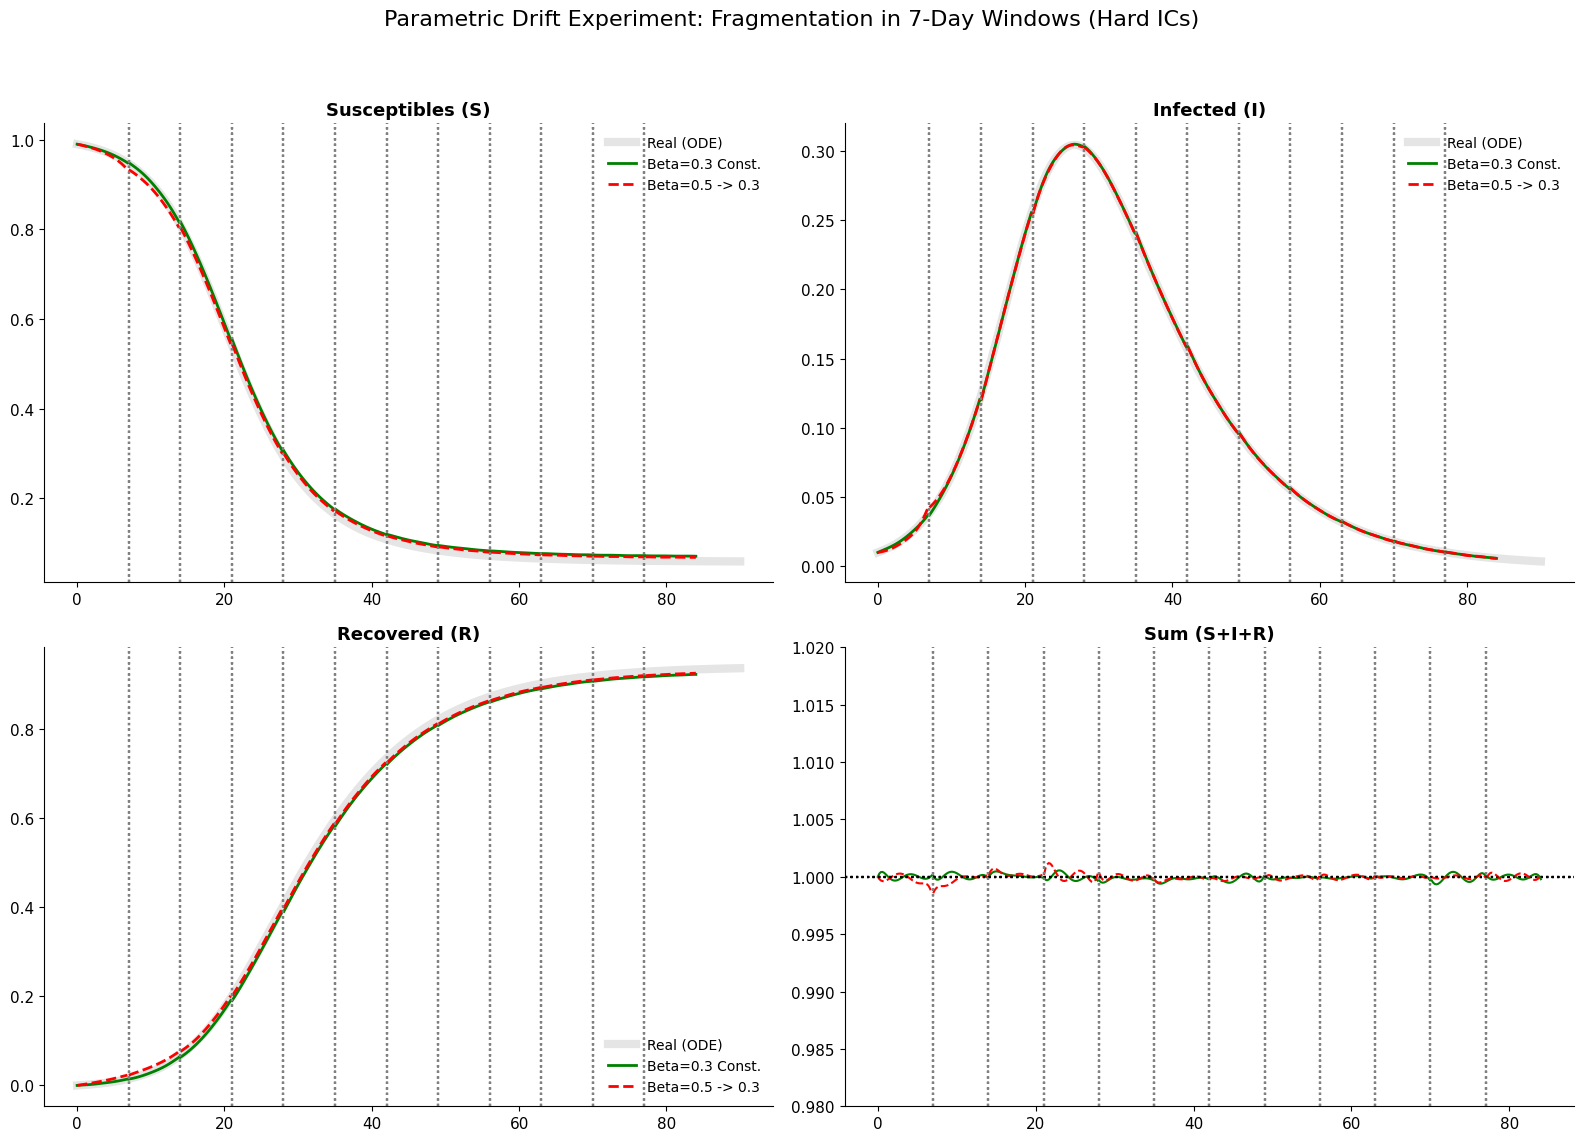

In [ ]:
run_windowed_simulation_hard_ic(7)


Running simulation with WINDOW_DURATION = 3 days (Hard ICs)
Training Green Window 1/30 (Beta 0.3)...
Training Red Window 1/30 (Beta 0.5)...
Training Green Window 2/30 (Beta 0.3)...
Training Red Window 2/30 (Beta 0.3)...
Training Green Window 3/30 (Beta 0.3)...
Training Red Window 3/30 (Beta 0.3)...
Training Green Window 4/30 (Beta 0.3)...
Training Red Window 4/30 (Beta 0.3)...
Training Green Window 5/30 (Beta 0.3)...
Training Red Window 5/30 (Beta 0.3)...
Training Green Window 6/30 (Beta 0.3)...
Training Red Window 6/30 (Beta 0.3)...
Training Green Window 7/30 (Beta 0.3)...
Training Red Window 7/30 (Beta 0.3)...
Training Green Window 8/30 (Beta 0.3)...
Training Red Window 8/30 (Beta 0.3)...
Training Green Window 9/30 (Beta 0.3)...
Training Red Window 9/30 (Beta 0.3)...
Training Green Window 10/30 (Beta 0.3)...
Training Red Window 10/30 (Beta 0.3)...
Training Green Window 11/30 (Beta 0.3)...
Training Red Window 11/30 (Beta 0.3)...
Training Green Window 12/30 (Beta 0.3)...
Training Red 

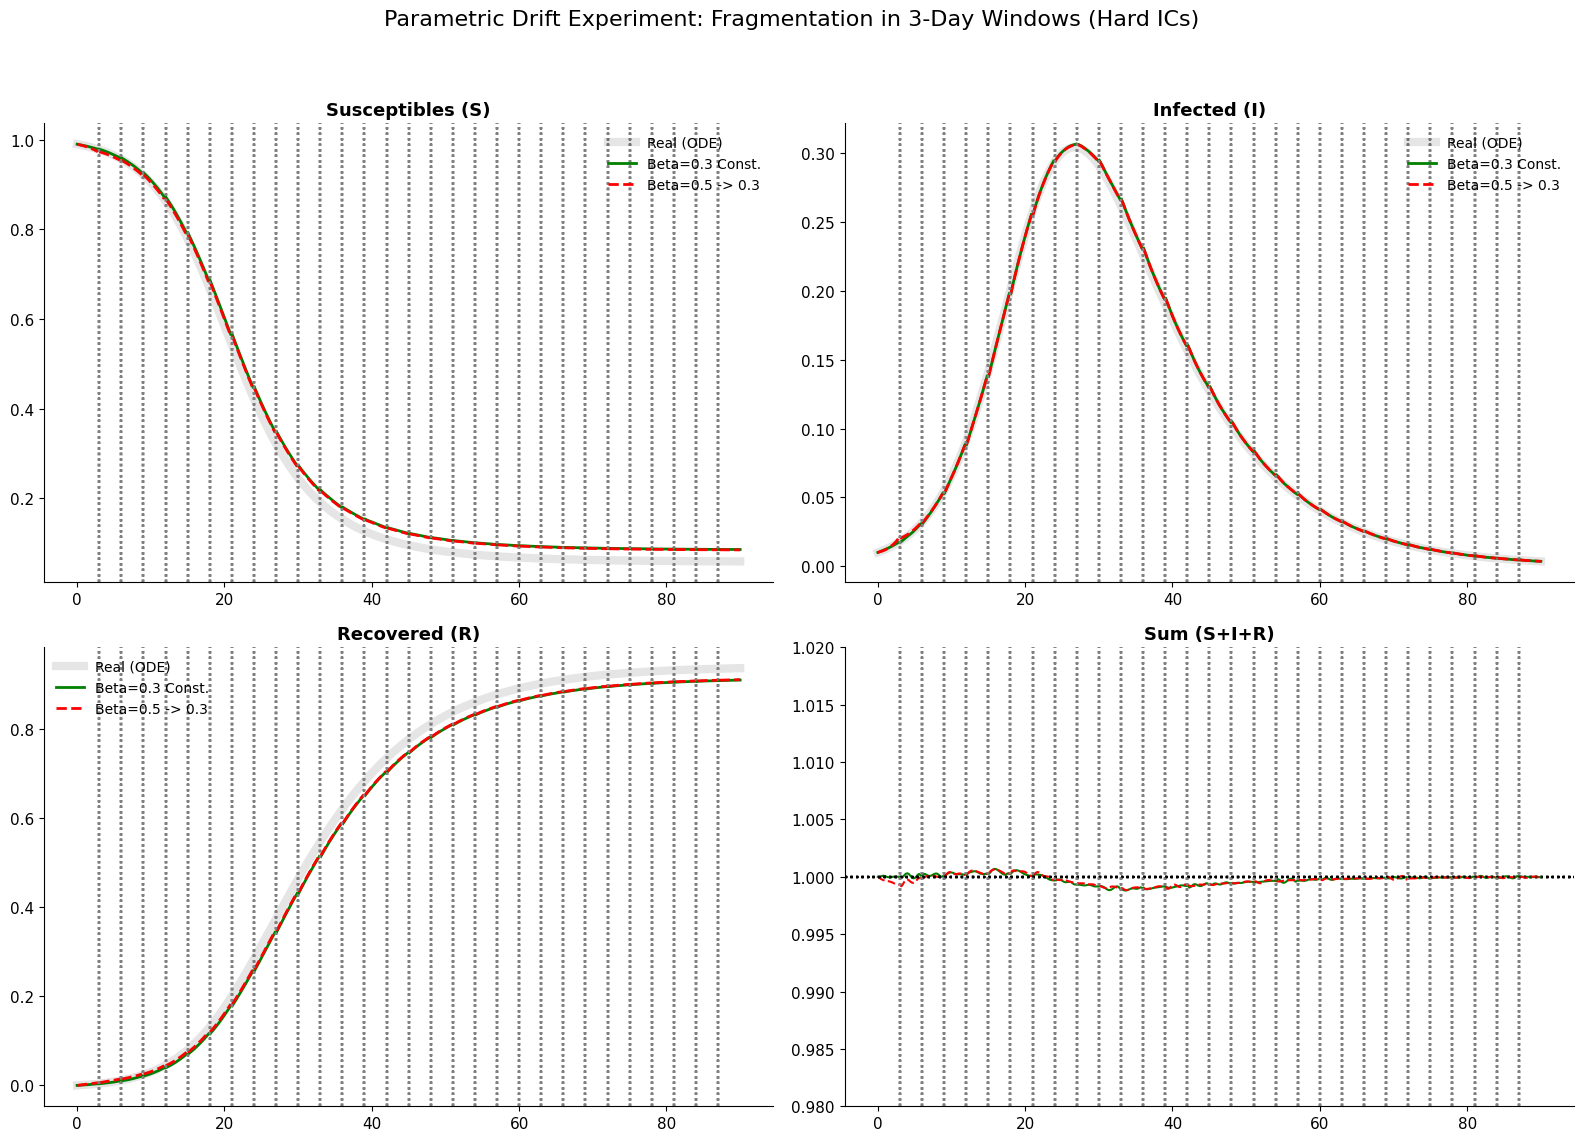

In [ ]:
run_windowed_simulation_hard_ic(3)